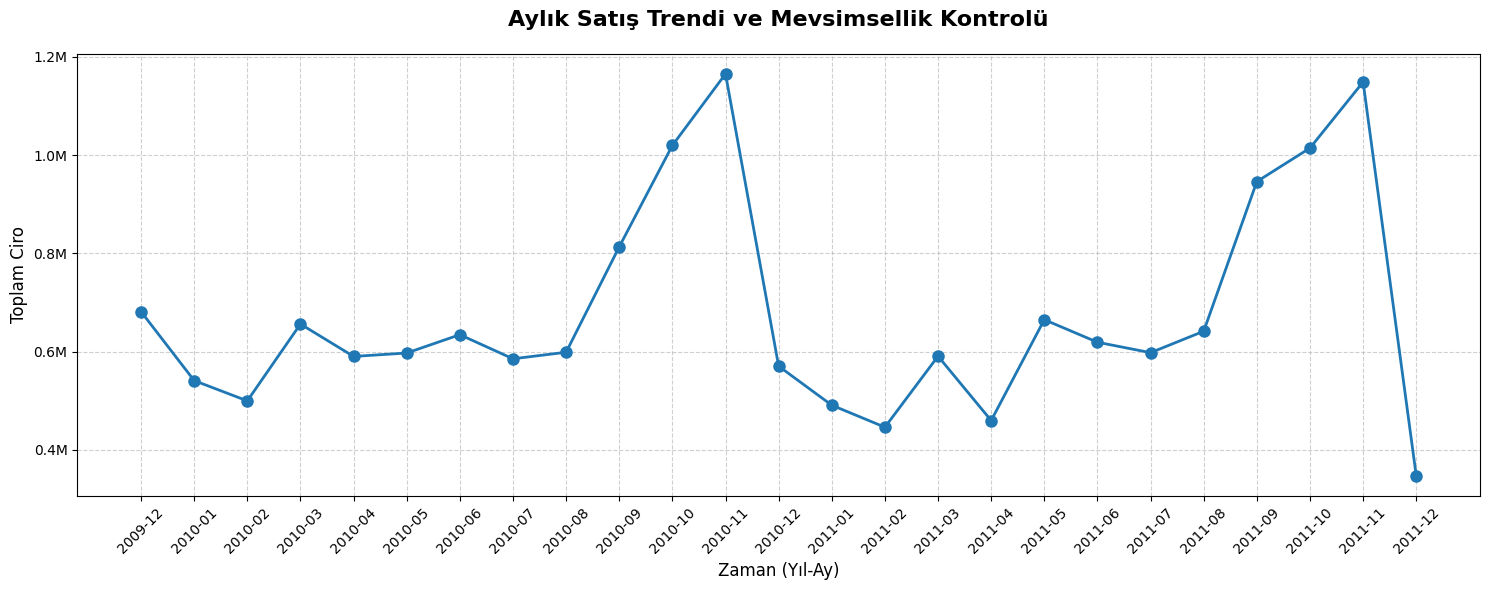

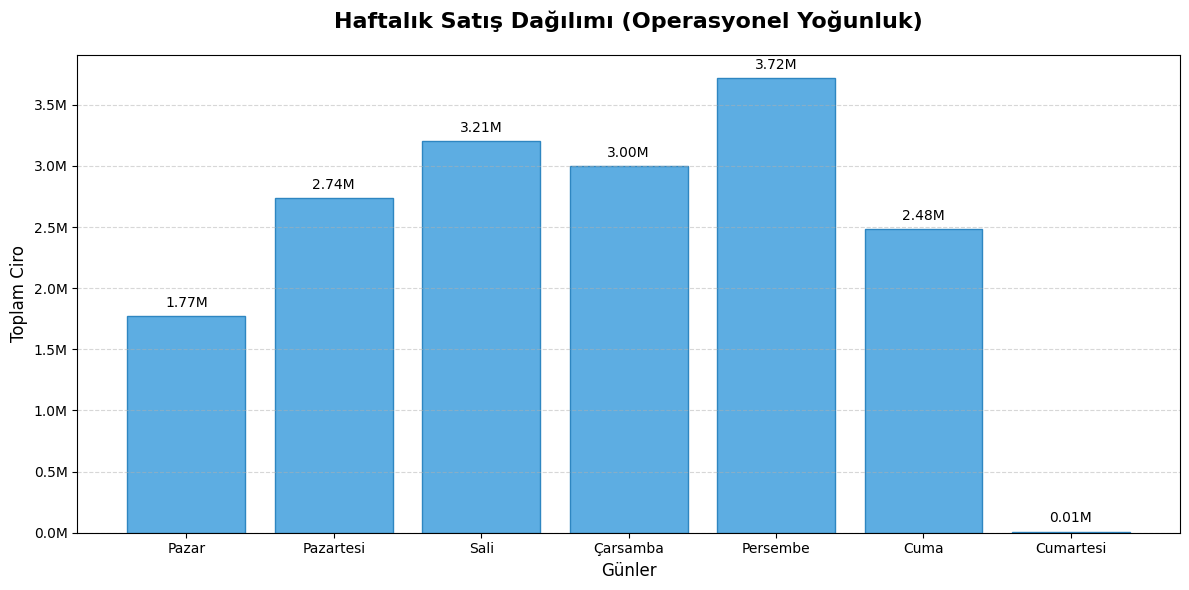

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

aylik_yolu = r'C:\Users\bngss\Downloads\AylikTrend.csv'
haftalik_yolu = r'C:\Users\bngss\Downloads\HaftalikTrend.csv'

try:
    df_ay = pd.read_csv(aylik_yolu)
    df_gun = pd.read_csv(haftalik_yolu)

    df_ay['Toplam_Ciro'] = pd.to_numeric(df_ay['Toplam_Ciro'].astype(str).str.replace(',', '.'), errors='coerce')
    df_gun['Gunluk_Toplam_Ciro'] = pd.to_numeric(df_gun['Gunluk_Toplam_Ciro'].astype(str).str.replace(',', '.'), errors='coerce')

    df_ay = df_ay.sort_values(['InvoiceYear', 'InvoiceMonth'])
    df_ay['Donem'] = df_ay['InvoiceYear'].astype(str) + "-" + df_ay['InvoiceMonth'].astype(str).str.zfill(2)

    df_gun = df_gun.sort_values('InvoiceWeekday')

    #AYLIK SATIŞ TRENDİ ÇİZİMİ
    plt.figure(figsize=(15, 6))
    plt.plot(df_ay['Donem'], df_ay['Toplam_Ciro'], marker='o', color='#1f77b4', linewidth=2, markersize=8)
    
    plt.title('Aylık Satış Trendi ve Mevsimsellik Kontrolü', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Zaman (Yıl-Ay)', fontsize=12)
    plt.ylabel('Toplam Ciro', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    formatter = ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
    plt.gca().yaxis.set_major_formatter(formatter)
    
    plt.tight_layout()
    plt.show()

    #HAFTALIK SATIŞ DAĞILIMI ÇİZİMİ
    plt.figure(figsize=(12, 6))
    bars = plt.bar(df_gun['Gun_Adi'], df_gun['Gunluk_Toplam_Ciro'], color='#5dade2', edgecolor='#2e86c1')
    
    plt.title('Haftalık Satış Dağılımı (Operasyonel Yoğunluk)', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Günler', fontsize=12)
    plt.ylabel('Toplam Ciro', fontsize=12)
    
    plt.gca().yaxis.set_major_formatter(formatter)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 50000, f'{yval/1e6:.2f}M', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Hata oluştu: {e}")